multiplex en frecuencia, discriminar entre paquetes de datos compartidos en un mismo medio

Modulacion de amplitud y frecuencia


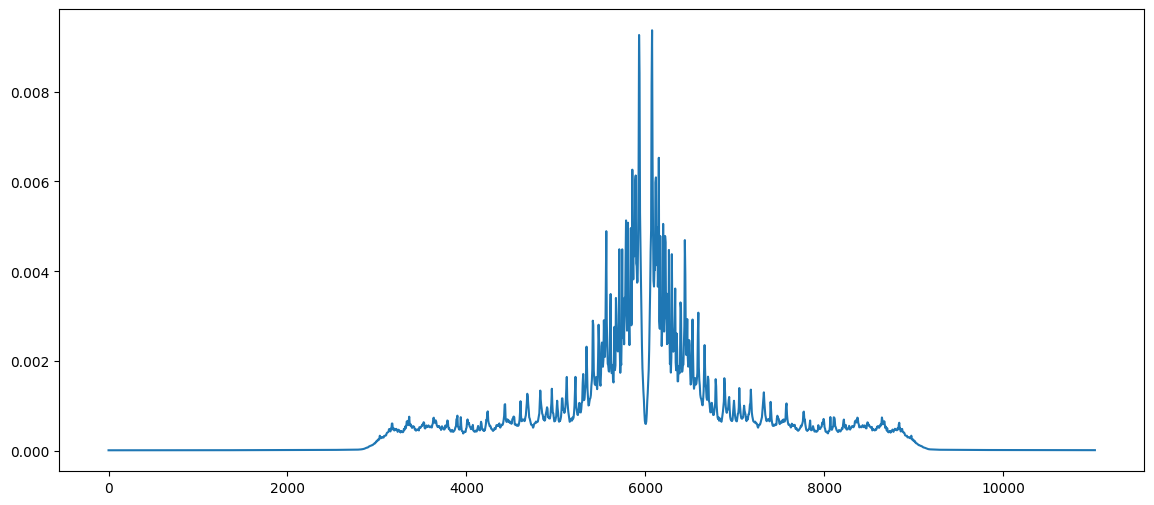

In [4]:
from IPython.display import Audio
import librosa
import numpy as np
import matplotlib.pyplot as plt
import wave
import scipy.signal as signal

#Frecuencia de una señal
def plot_frec(x,fs,fmax,m): 
    # esta función permite graficar las frecuencias de una señal x muestreada a tasa fs, 
    # el rango que grafica va hasta fmax, y m la  cantidad de puntos que toma para calcular la FFT .
    puntos = int(fmax/fs*m)  
    lx = len(x)
    nt = (lx + m - 1)//m
    xp = np.append(x,np.zeros(-lx+nt*m))
    xmw = np.reshape( xp, (m,nt), order='F')
    xmf = np.fft.fft(xmw,len(xmw),axis=0)/m
    xf = np.linspace(0, int(fs/2.0), int(m/2))
    plt.figure(figsize=(14,6))
    plt.plot(xf[0:puntos],np.abs(xmf[0:int(m/2),0:int(lx/m-1)]).mean(1)[0:puntos])
    plt.show()

#Filtros de señal
def filtro_pasabajo(x, f_corte, fs):
    taps = signal.firwin(151, f_corte, fs=fs)
    filtered_x = signal.lfilter(taps, 1.0, x)
    return filtered_x

def filtro_pasaalto(x, f_corte, fs):
    taps = signal.firwin(151, f_corte, pass_zero=False, fs=fs)
    filtered_x = signal.lfilter(taps, 1.0, x)
    return filtered_x

def filtro_pasabanda(x, f_corte1, f_corte2, fs):
    taps = signal.firwin(151, [f_corte1, f_corte2], pass_zero=False, fs=fs)    
    filtered_x = signal.lfilter(taps, 1.0, x)
    return filtered_x

data, fs = librosa.load('Jaime_24.wav')# le devuelve un numpy array con las muestras y la frecuencia de muestreo que utiliza esa canción.

#Las radios AM para asegurarse que lo que transmiten no tenga un ancho mayor a 10 kHz y por lo tanto que no se superponga con las emisoras que tiene
# al lado, filtran previo a transmitir el audio con un filtro pasa bajo de 10 kHz.
#Nosotros vamos a filtrar el audio a 3 kHz, o sea vamos a pasar el audio por un filtro pasabajo de frecuencia de corte 3000 Hz.
data_filt = filtro_pasabajo(data,3000,fs)


#Graficaremos la señal filtrada y la escucharemos.
#plot_frec(data_filt,fs,12000,4096)
#Audio(data_filt,rate=fs)


# En primer lugar generaremos un coseno de 10 KHz muestreado a una frecuencia de muestreo fs igual a la del audio filtrado que es de 24 kHz.
# Cuando vamos a multiplicar dos señales muesreadas en este caso el audio y el coseno ambos deben estar a la misma tasa de muestreo y
# tener la misma cantidad de muestras
f0 = 6000.0 # es la frecuencia portadora de nuestra radio AM
t=np.array([i for i in range(len(data_filt))])# genero un vector de tiempo
coseno = np.cos( 2*np.pi*f0/fs *t)
data_am = data_filt*coseno

#al multiplicarla por un coseno de frecuencia fc se traslada a la frecuencia fc
#si el espectro original estaba de 0 a 3kHz 
#ahora va de fc a fc + 3kHz

plot_frec(data_am,fs,15000,4096)




# TEOREMA DE MUESTREO


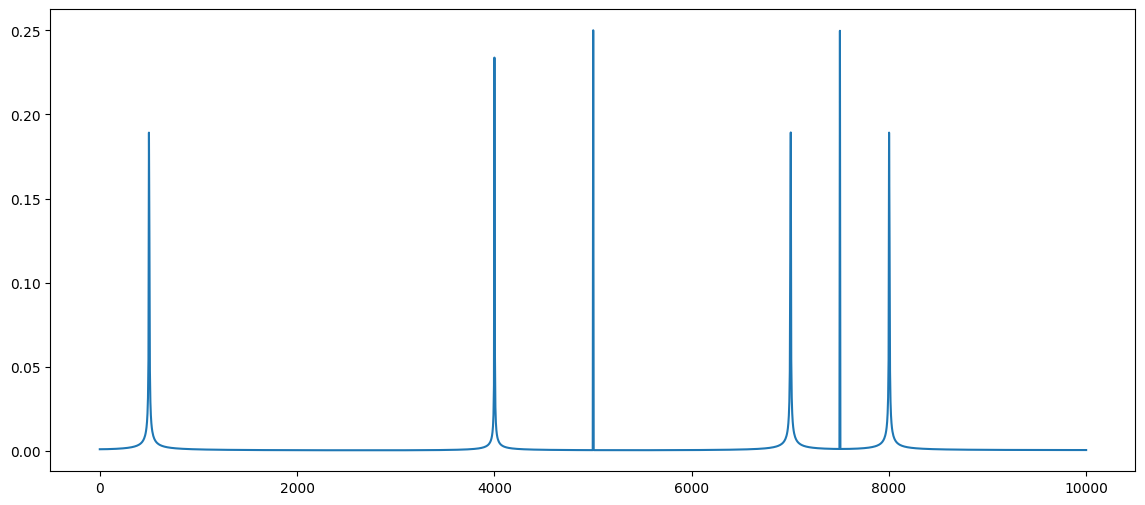

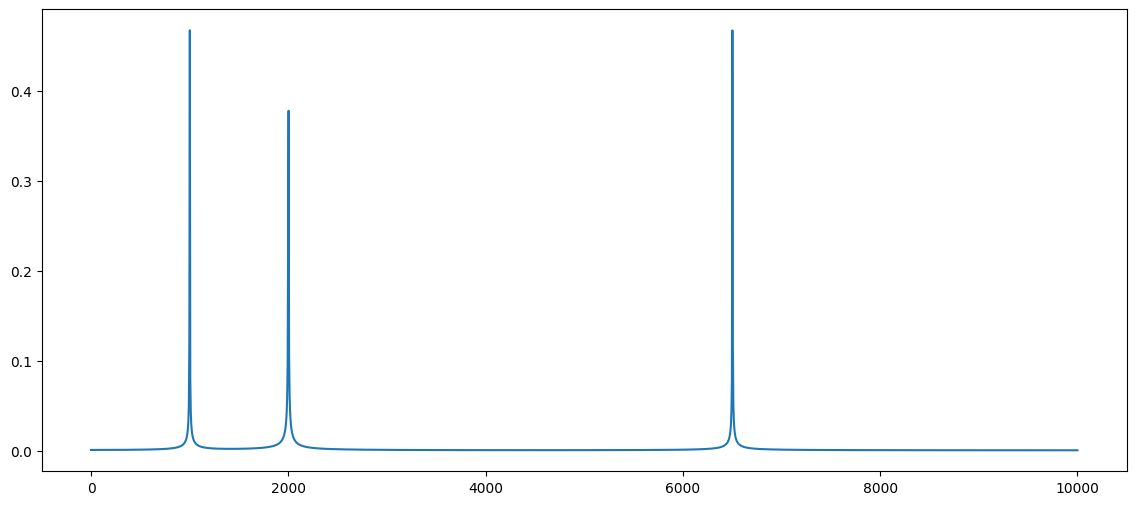

In [4]:
import numpy as np
from IPython.display import Audio
import librosa
import matplotlib.pyplot as plt
import wave
import scipy.signal as signal

#Frecuencia de una señal
def plot_frec(x,fs,fmax,m): 
    # esta función permite graficar las frecuencias de una señal x muestreada a tasa fs, 
    # el rango que grafica va hasta fmax, y m la  cantidad de puntos que toma para calcular la FFT .
    puntos = int(fmax/fs*m)  
    lx = len(x)
    nt = (lx + m - 1)//m
    xp = np.append(x,np.zeros(-lx+nt*m))
    xmw = np.reshape( xp, (m,nt), order='F')
    xmf = np.fft.fft(xmw,len(xmw),axis=0)/m
    xf = np.linspace(0, int(fs/2.0), int(m/2))
    plt.figure(figsize=(14,6))
    plt.plot(xf[0:puntos],np.abs(xmf[0:int(m/2),0:int(lx/m-1)]).mean(1)[0:puntos])
    plt.show()



fc = 6000.0 # es la frecuencia portadora de nuestra radio AM
fs = 20000
t=np.array([i for i in range(fs)])# genero un vector de tiempo
signal = np.sin( 2*np.pi*1000/fs *t)+ np.sin( 2*np.pi*2000/fs *t)+np.sin( 2*np.pi*6500/fs *t)

#a medida que 

coseno = np.cos( 2*np.pi*fc/fs *t)
data_am = signal*coseno
plot_frec(data_am,fs,12000,4096)
plot_frec(signal,fs,12000,4096)